In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [60]:
titanic = sns.load_dataset("titanic")

In [61]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [62]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [63]:
titanic.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [64]:
features = ["pclass","sex","embarked","fare","age"] #only use this feature
target = ["survived"]

In [65]:
#  missing value

from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_mode = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_mode.fit_transform(titanic[["embarked"]])

In [66]:
titanic.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [67]:
# encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [68]:
from os import X_OK
# split

X = titanic[features]
y = titanic[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [69]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 623 entries, 445 to 102
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    623 non-null    int64  
 1   sex       623 non-null    int64  
 2   embarked  623 non-null    int64  
 3   fare      623 non-null    float64
 4   age       623 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 29.2 KB


In [70]:
# desion Tree model
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [71]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

y_pred = model.predict(X_test)

print("accuracy: ", accuracy_score(y_test, y_pred))
print("precision: ", precision_score(y_test, y_pred))
print("recall :", recall_score(y_test, y_pred))
print("f1 score :", f1_score(y_test, y_pred))

accuracy:  0.7649253731343284
precision:  0.7222222222222222
recall : 0.7027027027027027
f1 score : 0.7123287671232876


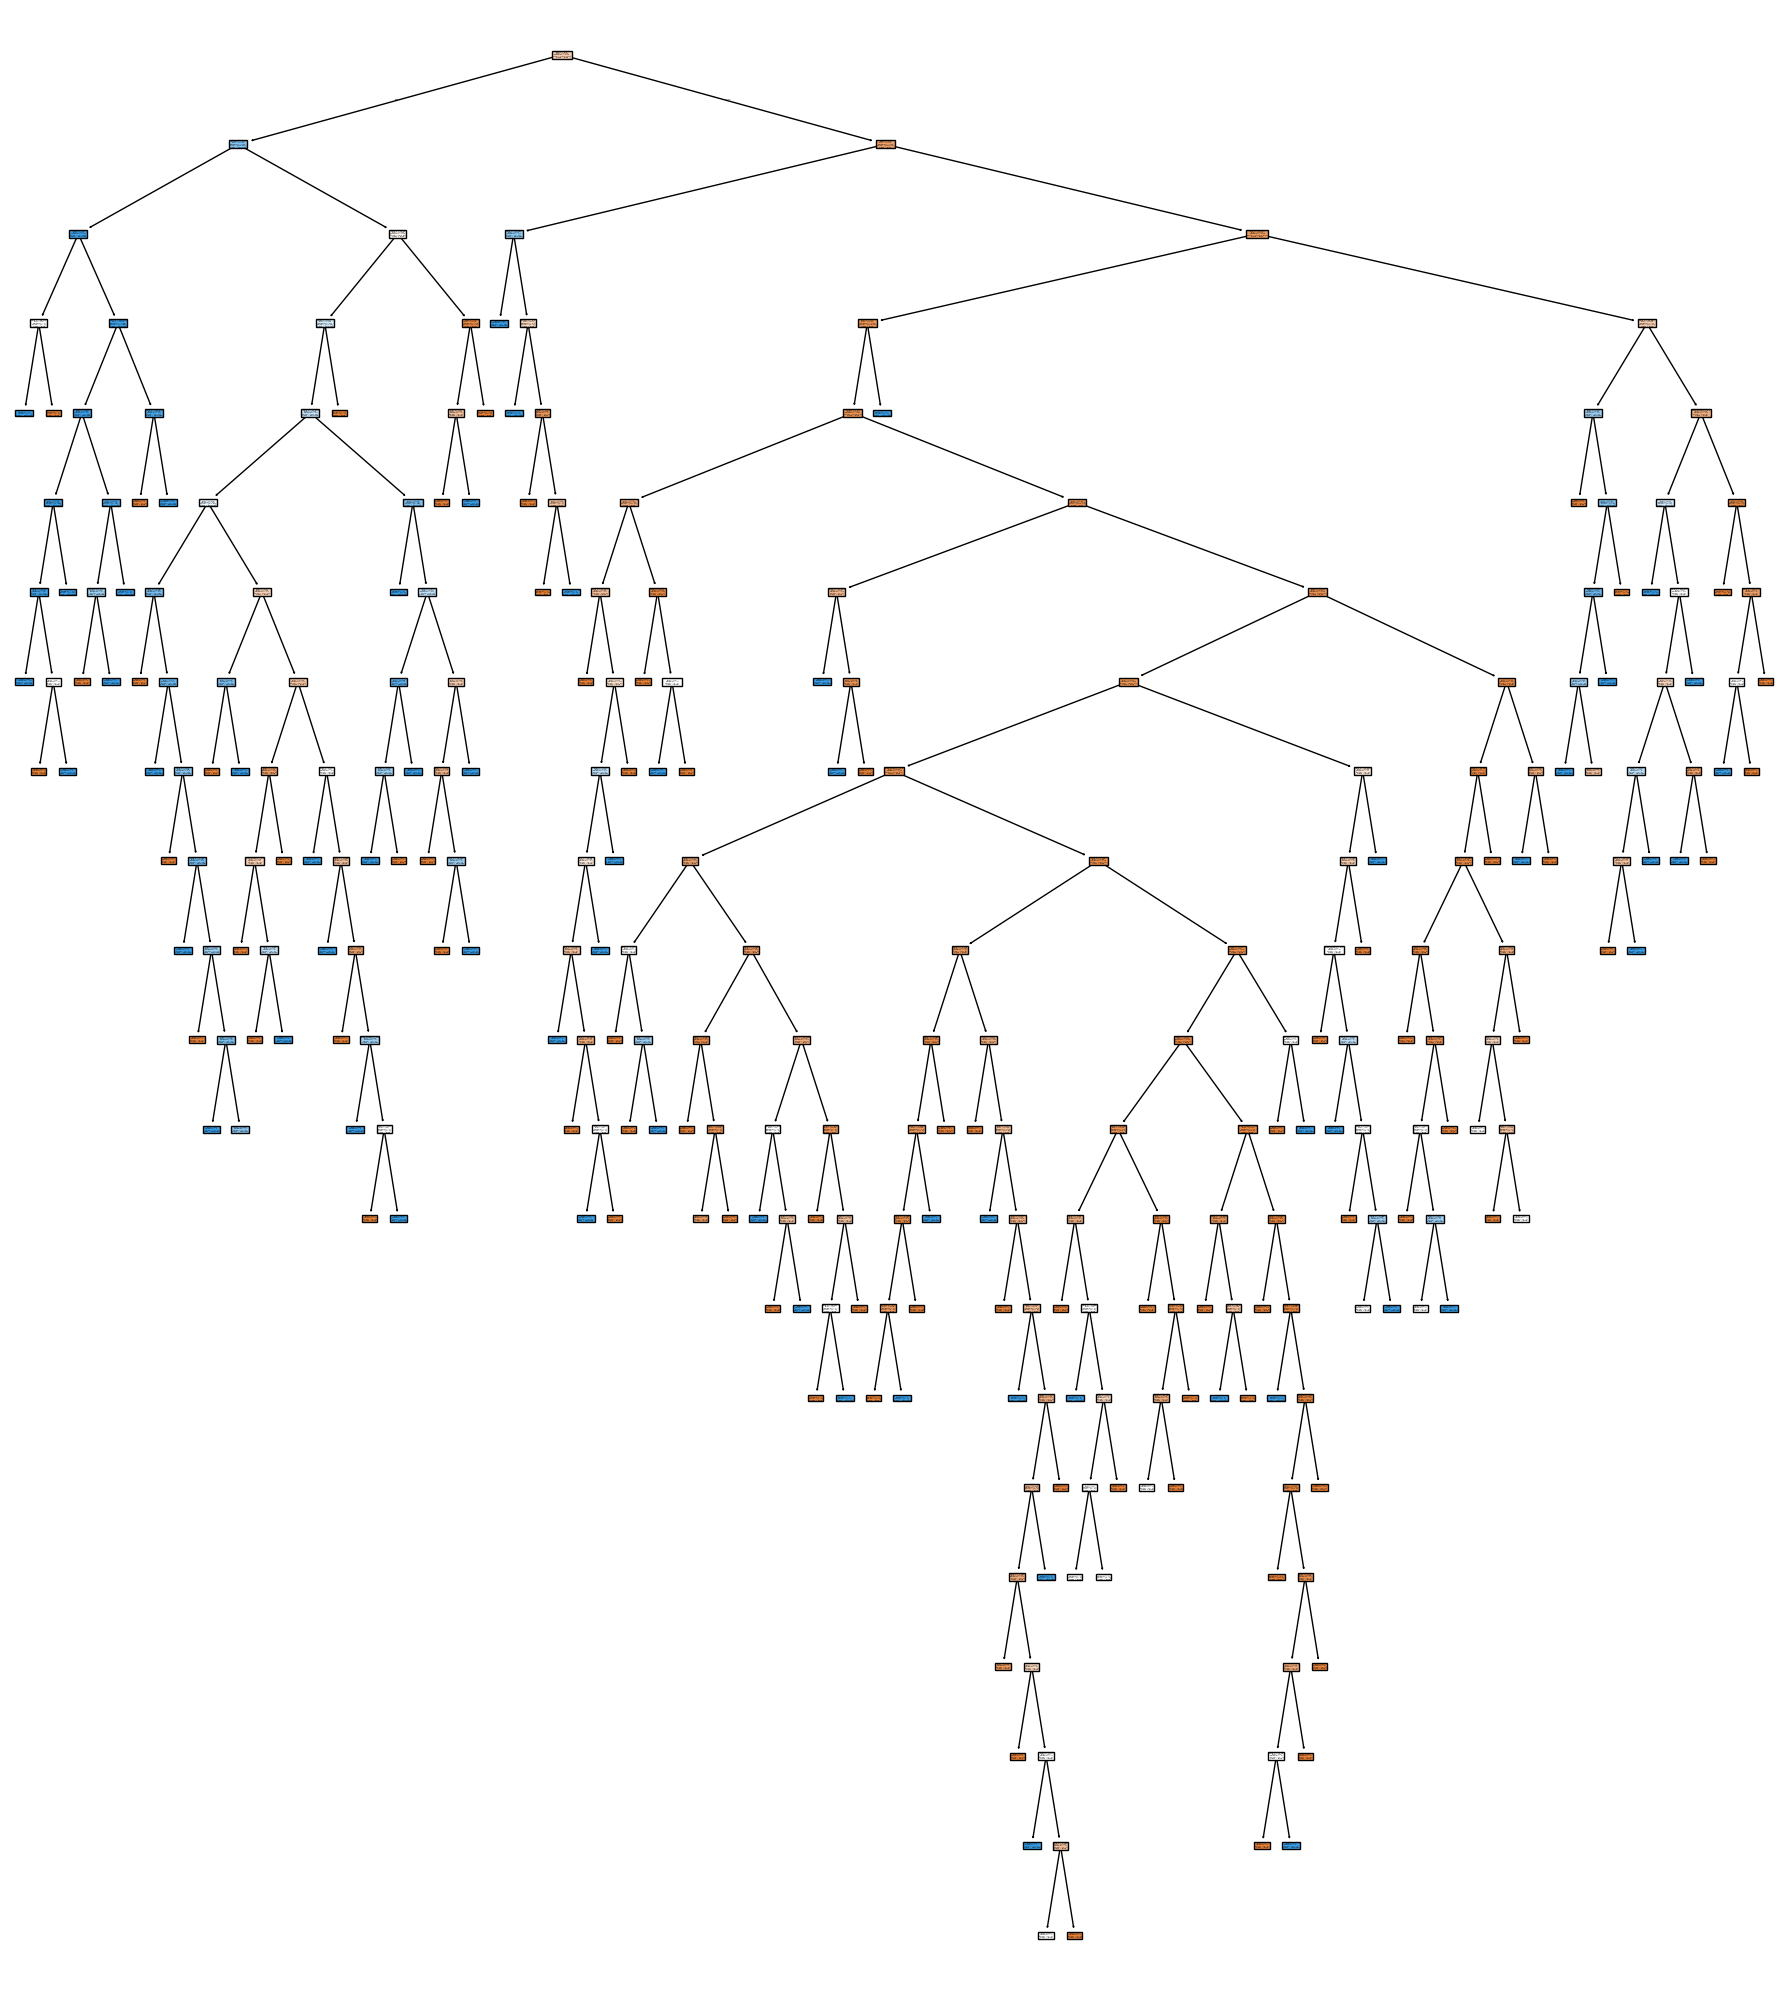

In [72]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,20))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["died","survived"],
    filled=True
  )

plt.tight_layout()
plt.show()

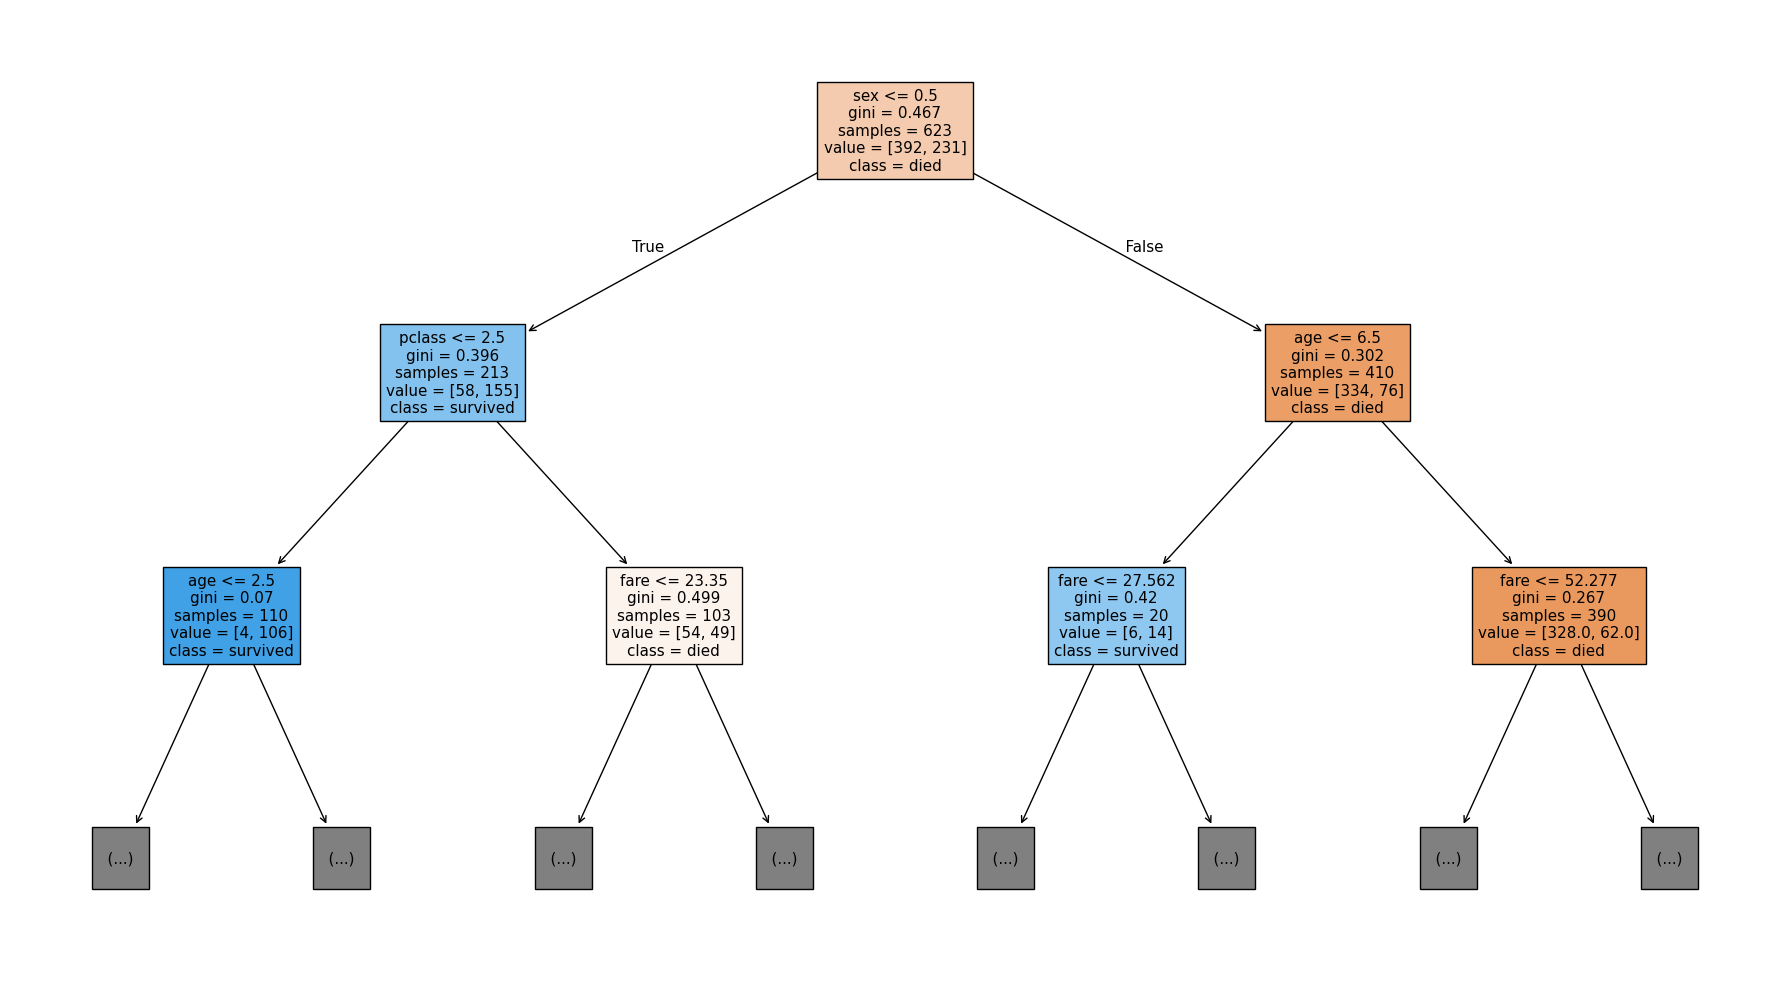

In [73]:
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["died","survived"],
    filled=True,
    max_depth=2, #show only two level
  )

plt.tight_layout()
plt.show()

In [74]:
# pre pruning :

max_depth = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

for i in max_depth:
  model = DecisionTreeClassifier(max_depth=i)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print(f"for Depth : {i} , accuracy : {accuracy_score(y_test, y_pred)}")

for Depth : 2 , accuracy : 0.7723880597014925
for Depth : 3 , accuracy : 0.8059701492537313
for Depth : 4 , accuracy : 0.8246268656716418
for Depth : 5 , accuracy : 0.7985074626865671
for Depth : 6 , accuracy : 0.7873134328358209
for Depth : 7 , accuracy : 0.7798507462686567
for Depth : 8 , accuracy : 0.8059701492537313
for Depth : 9 , accuracy : 0.7686567164179104
for Depth : 10 , accuracy : 0.7835820895522388
for Depth : 11 , accuracy : 0.7835820895522388
for Depth : 12 , accuracy : 0.7910447761194029
for Depth : 13 , accuracy : 0.7686567164179104
for Depth : 14 , accuracy : 0.7723880597014925
for Depth : 15 , accuracy : 0.7798507462686567


In [75]:
min_samples_split = [5, 10, 15, 20, 25, 30]

for i in min_samples_split:
  model = DecisionTreeClassifier(max_depth=10,min_samples_split=i)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print(f"for min_samples_split : {i} , accuracy : {accuracy_score(y_test, y_pred)}")

for min_samples_split : 5 , accuracy : 0.8022388059701493
for min_samples_split : 10 , accuracy : 0.7873134328358209
for min_samples_split : 15 , accuracy : 0.7649253731343284
for min_samples_split : 20 , accuracy : 0.7835820895522388
for min_samples_split : 25 , accuracy : 0.7723880597014925
for min_samples_split : 30 , accuracy : 0.7723880597014925


accuracy :  0.8246268656716418


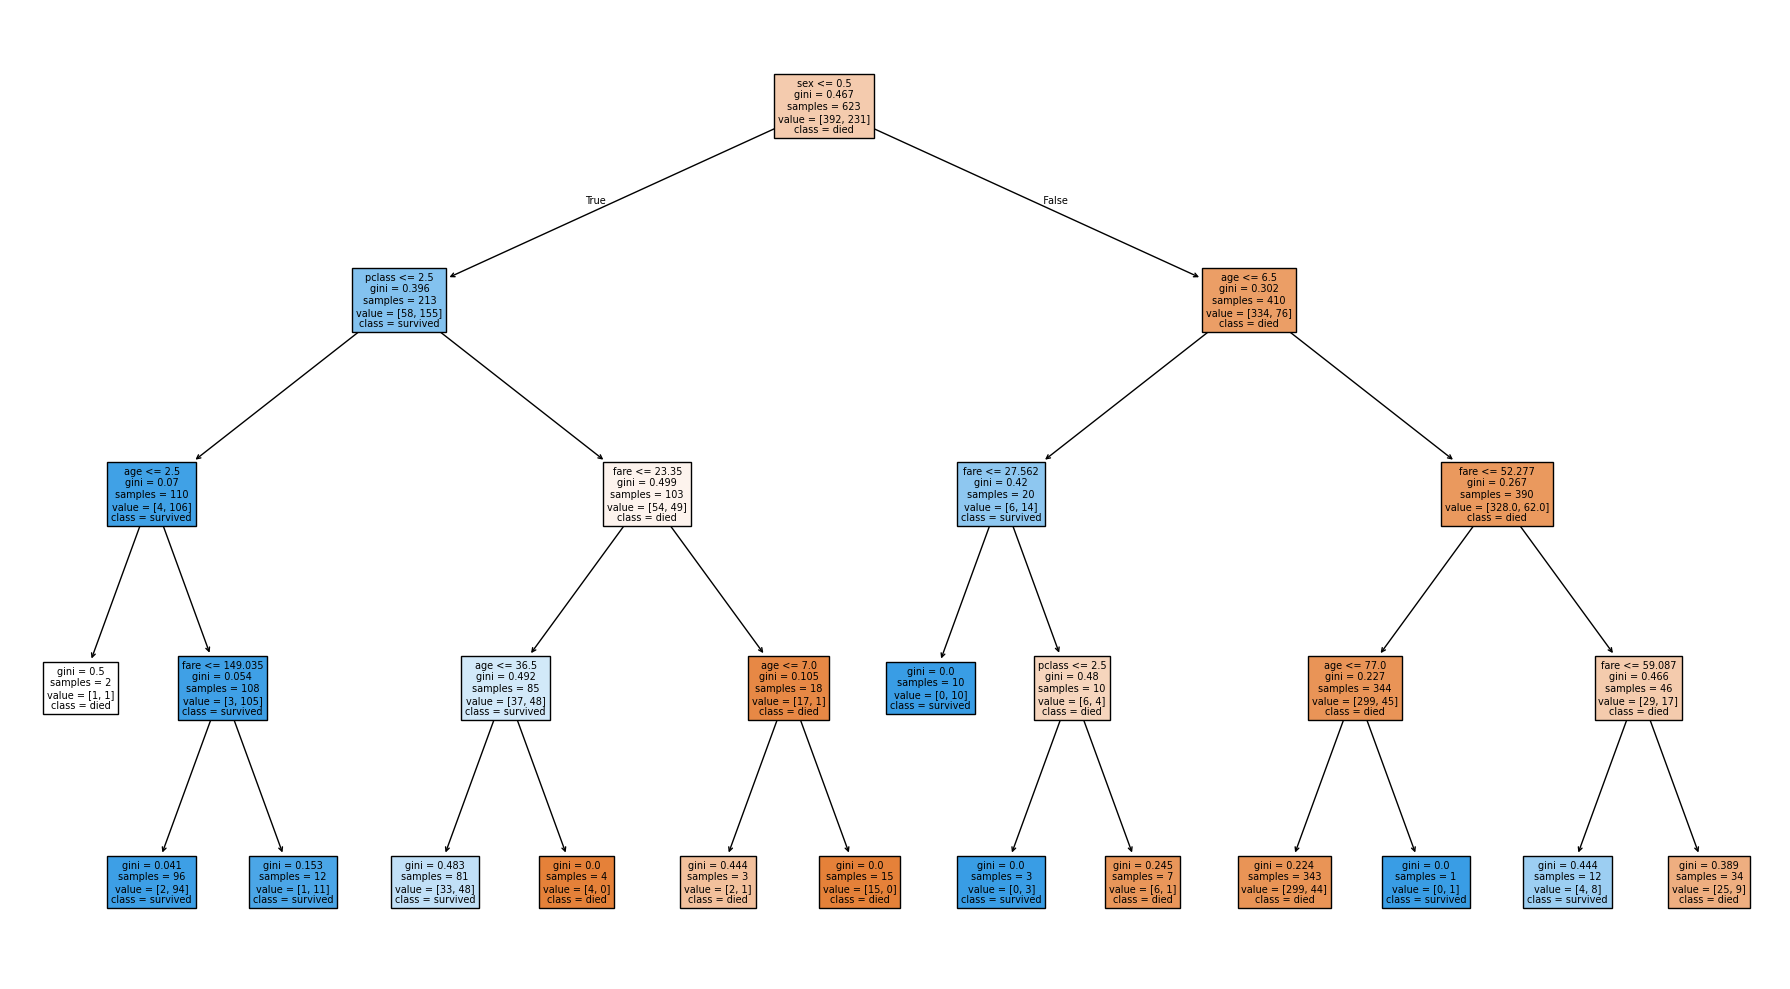

In [76]:
model = DecisionTreeClassifier(max_depth=4,min_samples_split=10)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("accuracy : ", accuracy_score(y_test, y_pred))

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["died","survived"],
    filled=True,
  )

plt.tight_layout()
plt.show()

In [77]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [79]:
path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.         0.         0.00013376 0.00013376 0.00022931 0.00032103
 0.00048409 0.00053505 0.00053505 0.00053505 0.00062746 0.00064205
 0.00077709 0.00085607 0.00093633 0.00096308 0.00096308 0.00096308
 0.00099875 0.00101659 0.00104193 0.0010478  0.00107009 0.00109238
 0.00115927 0.0012352  0.00123729 0.00129646 0.00132211 0.00133563
 0.00133761 0.00137583 0.00137583 0.00139708 0.00143228 0.00144145
 0.00150482 0.00151596 0.00152184 0.00167202 0.00171215 0.00183444
 0.0019012  0.00195674 0.00214018 0.00233474 0.0024077  0.00260835
 0.00263292 0.00278606 0.00280169 0.00284379 0.00288925 0.00299625
 0.00302412 0.00431144 0.00495299 0.00577849 0.00589431 0.0074248
 0.01236198 0.01787674 0.04065074 0.1323581 ]


In [83]:
# train our model for all alphas
trees = []

for alpha in ccp_alphas:
  model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
  model.fit(X_train, y_train)
  trees.append((model,alpha))

In [84]:
best_acc = 0
best_ccp_alpha = 0

for model,alpha in trees:
  curr_acc = model.score(X_test,y_test)
  if curr_acc > best_acc:
    best_acc = curr_acc
    best_ccp_alpha = alpha

print("best accuracy : ", best_acc)
print("best ccp alpha : ", best_ccp_alpha)

best accuracy :  0.8171641791044776
best ccp alpha :  0.0017121455323702516


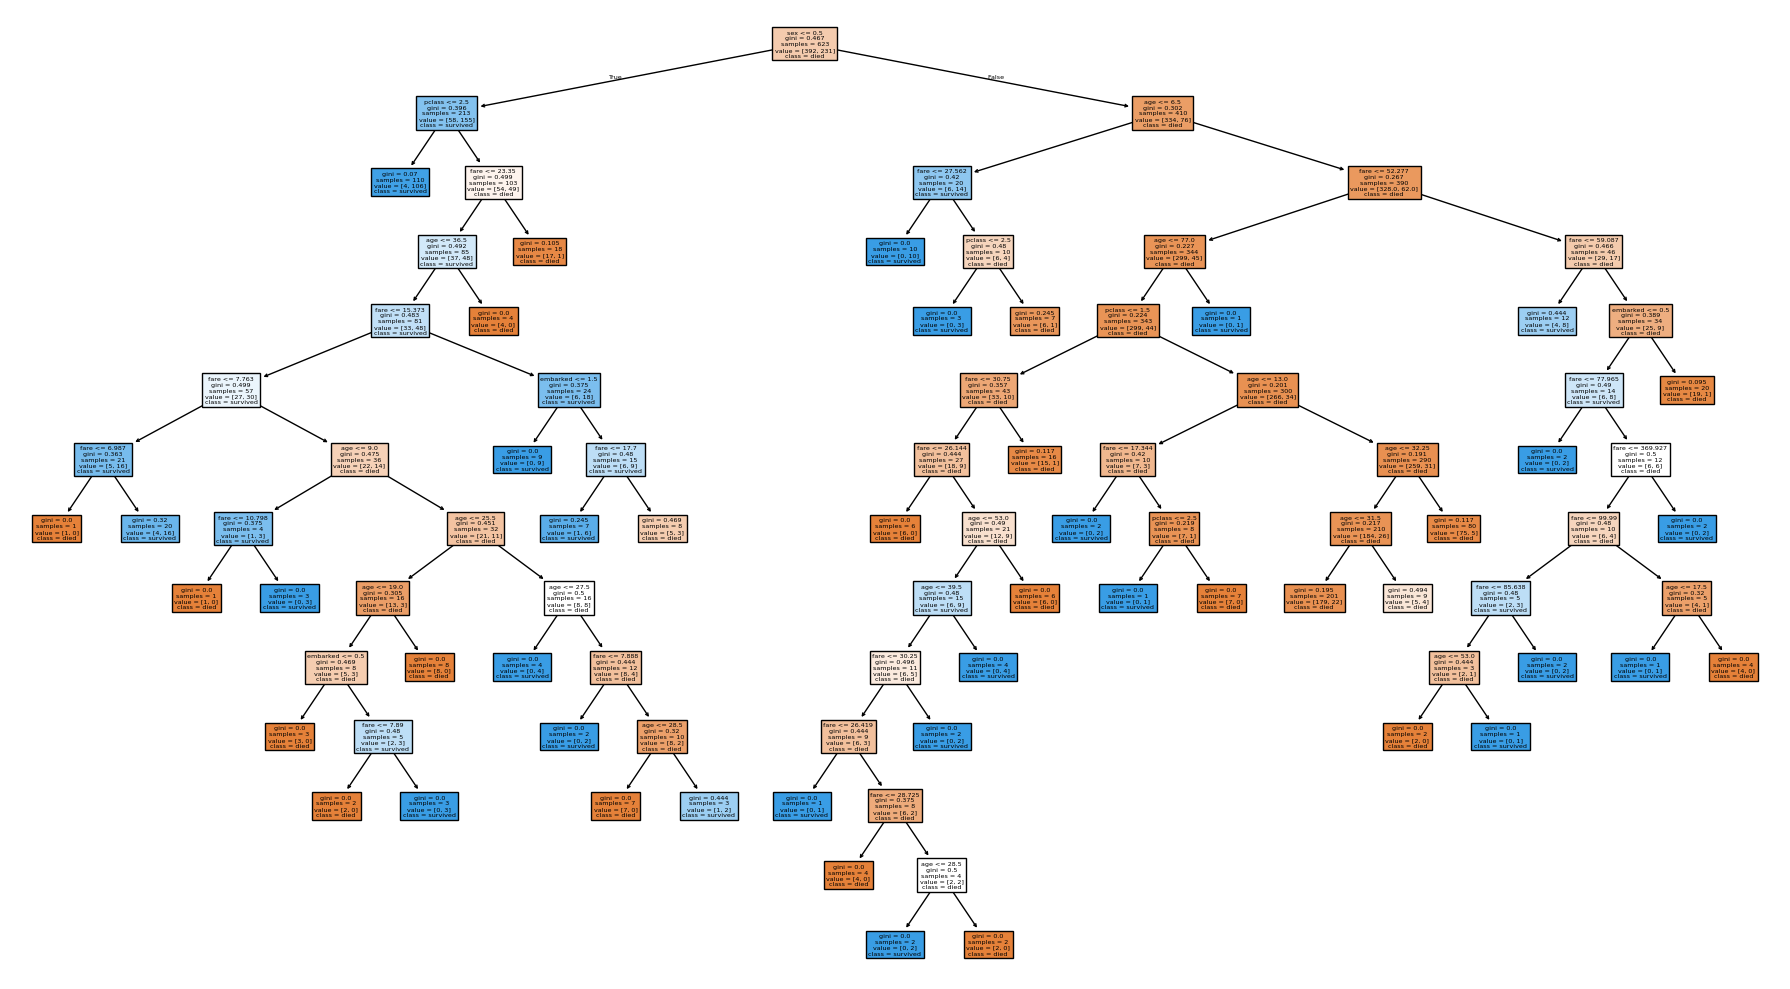

In [85]:
best_model = DecisionTreeClassifier(ccp_alpha=best_ccp_alpha)
best_model.fit(X_train, y_train)

plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["died","survived"],
    filled=True,
  )

plt.tight_layout()
plt.show()